<a href="https://colab.research.google.com/github/freisterortizguevara-wq/app-riesgo-frontend/blob/main/Arboles_de_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [13]:
import pandas as pd
df = pd.read_csv("diabetes.csv")
df

,Glucosa,PresionSanguinea,EspesorPiel,Insulina,IMC,ProbDiabetesHistFam,Edad,Resultado
0,148,72,35.0,113.0,33.6,0.627,50,1
1,85,66,29.0,88.5,26.6,0.351,31,0
2,183,64,24.0,227.5,23.3,0.672,32,1
3,89,66,23.0,94.0,28.1,0.167,21,0
4,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48.0,180.0,32.9,0.171,63,0
764,122,70,27.0,202.5,36.8,0.340,27,0
765,121,72,23.0,112.0,26.2,0.245,30,0
766,126,60,33.5,123.5,30.1,0.349,47,1


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Glucosa              768 non-null    int64  
 1   PresionSanguinea     768 non-null    int64  
 2   EspesorPiel          768 non-null    float64
 3   Insulina             768 non-null    float64
 4   IMC                  768 non-null    float64
 5   ProbDiabetesHistFam  768 non-null    float64
 6   Edad                 768 non-null    int64  
 7   Resultado            768 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 48.1 KB


In [15]:
df.describe()

,Glucosa,PresionSanguinea,EspesorPiel,Insulina,IMC,ProbDiabetesHistFam,Edad,Resultado
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,29.116536,155.886719,31.992578,0.471876,33.240885,0.348958
std,31.972618,19.355807,9.771631,105.112147,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,7.000000,14.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,22.000000,84.750000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,29.000000,129.500000,32.000000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,35.500000,194.000000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
df.Resultado.value_counts()

,count
Resultado,
0,500
1,268


tamaño set entrenamiento:  (537, 7) (537,)
tamaño set pruebas:  (231, 7) (231,)
distribucion original: 
Resultado
0    0.651042
1    0.348958
Name: proportion, dtype: float64
distribucion entrenamiento: 
Resultado
0    0.651769
1    0.348231
Name: proportion, dtype: float64
distribucion prueba: 
Resultado
0    0.649351
1    0.350649
Name: proportion, dtype: float64


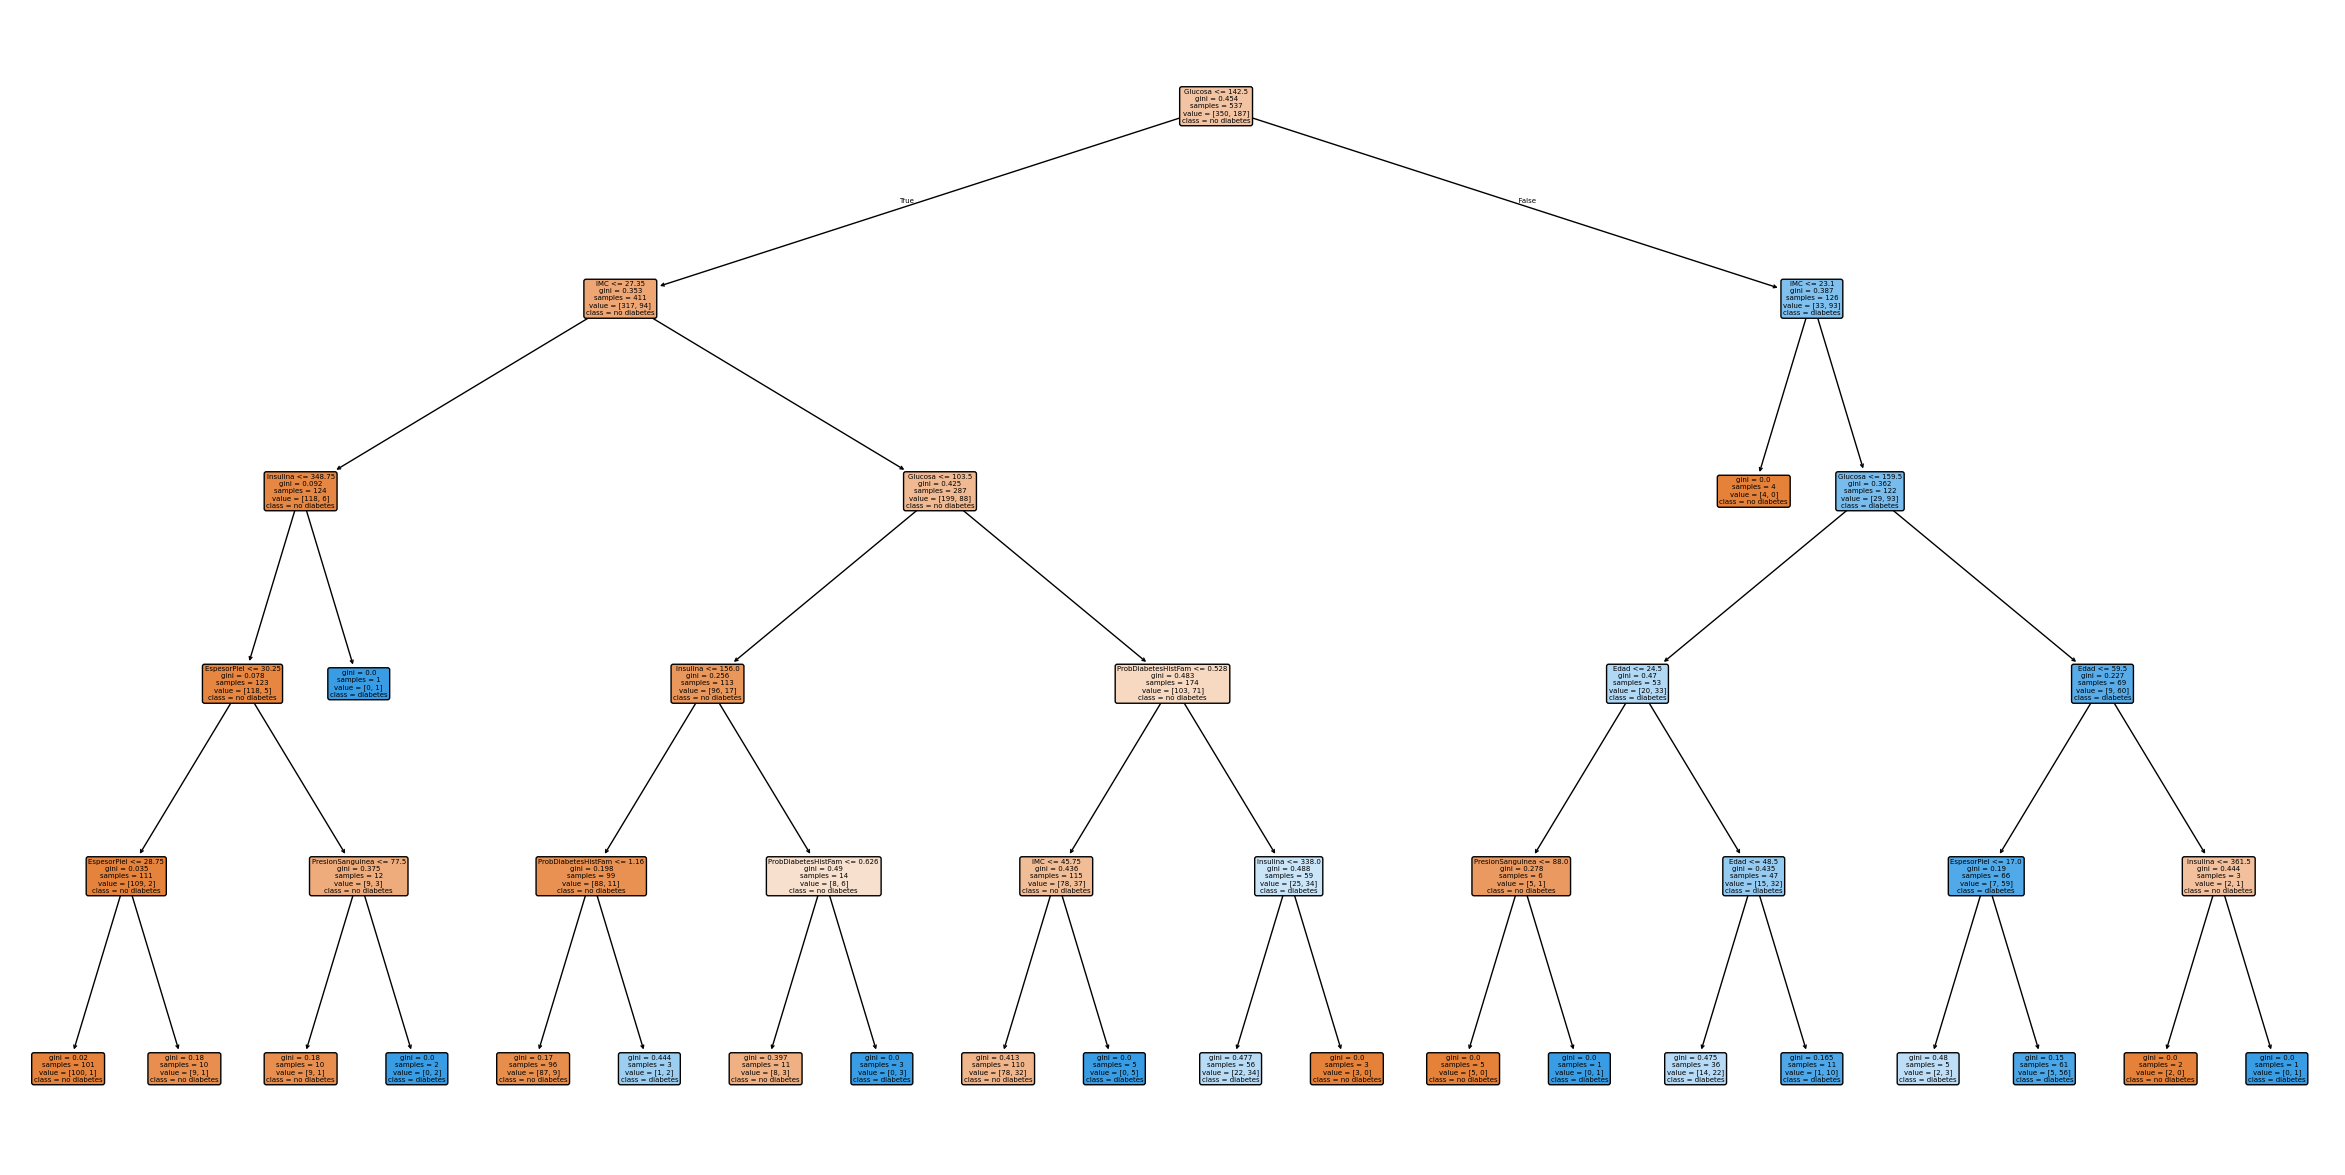

profundidad arbol:  5
numero de hojas arbol:  22


<Figure size 640x480 with 0 Axes>

In [27]:
from sklearn.model_selection import train_test_split

x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# ORDEN CORRECTO
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=123,
    stratify=y
)

print('tamaño set entrenamiento: ', x_train.shape, y_train.shape)
print('tamaño set pruebas: ', x_test.shape, y_test.shape)

print('distribucion original: ')
print(y.value_counts(normalize=True))

print('distribucion entrenamiento: ')
print(y_train.value_counts(normalize=True))

print('distribucion prueba: ')
print(y_test.value_counts(normalize=True))


from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(max_depth=5,random_state=123)

# ENTRENAR MODELO
arbol.fit(x_train, y_train)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,15))

plot_tree(
    arbol,
    feature_names=x_train.columns,
    class_names=['no diabetes', 'diabetes'],
    filled=True,
    rounded=True
)

# MOSTRAR FIGURA
plt.show()

# GUARDAR IMAGEN
plt.savefig('arbol_clasificacion.png', dpi=700)

print('profundidad arbol: ', arbol.get_depth())
print('numero de hojas arbol: ', arbol.get_n_leaves())

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=123)

arbol = DecisionTreeClassifier(max_depth=5,random_state=123)
scores = cross_val_score (arbol, x_train, y_train, cv =skf ,scoring='f1_weighted')

# Fit the model after cross-validation to use its score method
arbol.fit(x_train, y_train)

print('F1 SCORE PONDERADO: ', scores.mean())
score_test = arbol.score(x_test, y_test)
print('score de prueba: ',score_test)

F1 SCORE PONDERADO:  0.6921307568115952
score de prueba:  0.7359307359307359
